In [1]:
import os
import re
import json
from typing import Dict, List, Optional, Tuple, Iterable

import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from shapely.geometry import mapping, Polygon
import networkx as nx


class TreeTrackingGraph:
    """
    Self-contained tracker for tree crowns across orthomosaics using a directed graph.

    What this class does:
    - Discovers input files under input/input_crowns (*.gpkg) and input/input_om (*.tif)
    - Loads crown polygons (GeoPackages) and optionally extracts orthomosaic image patches per crown
    - Computes crown attributes (centroid, area, compactness, eccentricity, etc.)
    - Builds a tracking graph with threshold-only matching (multiple edges allowed), no Hungarian
    - Computes quality metrics and graph-complexity metrics
    - Performs threshold sweeps and saves results as JSON/TXT
    - Provides basic visualizations (static chain plots, OM overlays) and an optional interactive overview

    Typical usage:
      tracker = TreeTrackingGraph()
      tracker.load_data(load_images=False)
      tracker.build_graph_threshold(threshold=0.5)
      report, metrics = tracker.quality_report()
      comp_report, comp_metrics = tracker.complexity_report()
      sweep = tracker.sweep_thresholds([0.0, 0.1, ..., 1.0])
      # Visualization (optional):
      chain = tracker.get_matching_chain(start_om_id=1, crown_id=0)
      tracker.plot_matching_chain(chain, show_images=False)

    Notes:
    - Matching is between consecutive orthomosaics only (OM i -> OM i+1)
    - Multiple edges from one node are allowed if similarity >= threshold
    - You can gate by max centroid distance and/or minimum IoU to reduce spurious edges
    """

    # ----------------------------
    # Construction and discovery
    # ----------------------------
    def __init__(
        self,
        crown_dir: Optional[str] = None,
        ortho_dir: Optional[str] = None,
        output_dir: str = '../../output',
        simplify_tol: float = 1.0,
        max_crowns_preview: int = 200,
        auto_discover: bool = True,
    ) -> None:
        self.output_dir = output_dir
        self.simplify_tol = simplify_tol
        self.max_crowns_preview = max_crowns_preview

        # Directories
        self.crown_dir = crown_dir or self._resolve_dir('input/input_crowns', '../../input/input_crowns')
        self.ortho_dir = ortho_dir or self._resolve_dir('input/input_om', '../../input/input_om')

        # File mappings and data containers
        self.file_pairs: List[Tuple[str, str]] = []  # (crown_gpkg, ortho_tif)
        self.om_ids: List[int] = []                 # Sorted list of OM numeric ids
        self.crowns_gdfs: Dict[int, gpd.GeoDataFrame] = {}
        self.crown_attrs: Dict[int, List[Dict]] = {}
        self.crown_images: Dict[int, List[Optional[np.ndarray]]] = {}

        # Graph
        self.G: nx.DiGraph = nx.DiGraph()

        if auto_discover:
            self.discover_files()

    @staticmethod
    def _resolve_dir(root_rel: str, nb_rel: str) -> str:
        candidates = [
            os.path.abspath(os.path.join(os.getcwd(), root_rel)),
            os.path.abspath(os.path.join(os.getcwd(), nb_rel)),
        ]
        for p in candidates:
            if os.path.isdir(p):
                return p
        raise FileNotFoundError(f"Could not resolve directory for {root_rel}. Tried: {candidates}")

    @staticmethod
    def _extract_numeric_id(name: str) -> Optional[int]:
        """Extract first integer found in a filename (e.g., OM3.gpkg -> 3, sit_om12.tif -> 12)."""
        m = re.search(r"(\d+)", os.path.basename(name))
        return int(m.group(1)) if m else None

    def discover_files(self) -> None:
        """
        Discover and pair crown .gpkg files and orthomosaic .tif files.
        Tries to pair by numeric id embedded in filenames; if missing, pairs by sorted order.
        Populates self.file_pairs and self.om_ids.
        """
        crown_files = [os.path.join(self.crown_dir, f) for f in os.listdir(self.crown_dir) if f.lower().endswith('.gpkg')]
        ortho_files = [os.path.join(self.ortho_dir, f) for f in os.listdir(self.ortho_dir) if f.lower().endswith('.tif')] if os.path.exists(self.ortho_dir) else []
        if not crown_files:
            raise FileNotFoundError(f"No .gpkg crown files found in {self.crown_dir}")
        if not ortho_files:
            # It's allowed to run without orthos if only polygons are needed
            ortho_files = []

        crowns_by_id = {}
        for cf in crown_files:
            cid = self._extract_numeric_id(cf)
            crowns_by_id[cid if cid is not None else cf] = cf

        orthos_by_id = {}
        for of in ortho_files:
            oid = self._extract_numeric_id(of)
            orthos_by_id[oid if oid is not None else of] = of

        # Intersect numeric ids if possible; otherwise fallback to sorted order
        numeric_ids = sorted(set(k for k in crowns_by_id.keys() if isinstance(k, int)) & set(k for k in orthos_by_id.keys() if isinstance(k, int)))
        file_pairs: List[Tuple[str, str]] = []
        if numeric_ids:
            for nid in numeric_ids:
                file_pairs.append((crowns_by_id[nid], orthos_by_id[nid]))
            # Collect any crown-only entries that don't have an ortho pair
            crown_only = sorted(k for k in crowns_by_id.keys() if isinstance(k, int) and k not in numeric_ids)
            for nid in crown_only:
                file_pairs.append((crowns_by_id[nid], None))
        else:
            # Fallback: zip sorted by name
            crown_files_sorted = sorted(crown_files)
            ortho_files_sorted = sorted(ortho_files)
            for i, cf in enumerate(crown_files_sorted):
                of = ortho_files_sorted[i] if i < len(ortho_files_sorted) else None
                file_pairs.append((cf, of))

        # Determine OM ids in order
        om_ids: List[int] = []
        for cf, _ in file_pairs:
            cid = self._extract_numeric_id(cf)
            om_ids.append(cid if cid is not None else len(om_ids) + 1)

        # Sort by om id while keeping pairs aligned
        pairs_with_id = sorted([(oid, cf, of) for oid, (cf, of) in zip(om_ids, file_pairs)], key=lambda x: x[0])
        self.file_pairs = [(cf, of) for _, cf, of in pairs_with_id]
        self.om_ids = [oid for oid, _, _ in pairs_with_id]

    # ----------------------------
    # Loading and attributes
    # ----------------------------
    def load_data(self, load_images: bool = False) -> None:
        """
        Load crowns and compute attributes for each OM. Optionally extract image patches for each crown.
        Results are stored in:
          - self.crowns_gdfs[om_id] -> GeoDataFrame
          - self.crown_attrs[om_id] -> List[dict] per crown
          - self.crown_images[om_id] -> List[np.ndarray|None] per crown (only if load_images=True and .tif exists)
        """
        self.crowns_gdfs.clear()
        self.crown_attrs.clear()
        self.crown_images.clear()

        for om_id, (crown_file, ortho_file) in zip(self.om_ids, self.file_pairs):
            gdf = gpd.read_file(crown_file)
            self.crowns_gdfs[om_id] = gdf
            self.crown_attrs[om_id] = [self._compute_crown_attributes(row.geometry) for _, row in gdf.iterrows()]

            if load_images and ortho_file and os.path.exists(ortho_file):
                with rasterio.open(ortho_file) as src:
                    patches: List[Optional[np.ndarray]] = []
                    for _, row in gdf.iterrows():
                        geom = [mapping(row.geometry)]
                        try:
                            out_image, _ = mask(src, geom, crop=True)
                            img_patch = np.moveaxis(out_image, 0, -1)
                        except Exception:
                            img_patch = None
                        patches.append(img_patch)
                self.crown_images[om_id] = patches
            else:
                self.crown_images[om_id] = [None] * len(gdf)

    @staticmethod
    def _compute_crown_attributes(geometry) -> Dict:
        centroid = geometry.centroid
        area = geometry.area
        perimeter = geometry.length
        bounds = geometry.bounds
        compactness = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0
        # Eccentricity via minimum rotated rectangle
        try:
            min_rect = geometry.minimum_rotated_rectangle
            coords = list(min_rect.exterior.coords)
            side1 = np.linalg.norm(np.array(coords[0]) - np.array(coords[1]))
            side2 = np.linalg.norm(np.array(coords[1]) - np.array(coords[2]))
            major_axis = max(side1, side2)
            minor_axis = min(side1, side2)
            eccentricity = minor_axis / major_axis if major_axis > 0 else 1
        except Exception:
            eccentricity = 1
        aspect_ratio = (bounds[3] - bounds[1]) / (bounds[2] - bounds[0]) if bounds[2] != bounds[0] else 1
        return {
            'geometry': geometry,
            'centroid': centroid,
            'area': area,
            'perimeter': perimeter,
            'compactness': compactness,
            'eccentricity': eccentricity,
            'aspect_ratio': aspect_ratio,
            'bounds': bounds,
        }

    # ----------------------------
    # Similarity and IoU
    # ----------------------------
    @staticmethod
    def _compute_iou(g1, g2) -> float:
        intersection = g1.intersection(g2).area
        union = g1.union(g2).area
        return intersection / union if union > 0 else 0.0

    def _weighted_similarity(
        self,
        a1: Dict,
        a2: Dict,
        weights: Optional[Dict[str, float]] = None,
        max_dist: float = 100.0,
    ) -> Tuple[float, Dict[str, float]]:
        if weights is None:
            weights = {'spatial': 0.4, 'area': 0.2, 'shape': 0.2, 'iou': 0.2}
        centroid_dist = a1['centroid'].distance(a2['centroid'])
        spatial_sim = max(0.0, 1.0 - (centroid_dist / max_dist))
        area_sim = min(a1['area'], a2['area']) / max(a1['area'], a2['area']) if max(a1['area'], a2['area']) > 0 else 0.0
        compactness_sim = 1.0 - abs(a1['compactness'] - a2['compactness'])
        eccentricity_sim = 1.0 - abs(a1['eccentricity'] - a2['eccentricity'])
        shape_sim = (compactness_sim + eccentricity_sim) / 2.0
        iou_sim = self._compute_iou(a1['geometry'], a2['geometry'])
        total = (
            weights.get('spatial', 0.0) * spatial_sim +
            weights.get('area', 0.0) * area_sim +
            weights.get('shape', 0.0) * shape_sim +
            weights.get('iou', 0.0) * iou_sim
        )
        return total, {
            'spatial': float(spatial_sim),
            'area': float(area_sim),
            'shape': float(shape_sim),
            'iou': float(iou_sim),
            'total': float(total),
        }

    # ----------------------------
    # Graph building (threshold-only)
    # ----------------------------
    def reset_graph(self) -> None:
        self.G = nx.DiGraph()

    def build_graph_threshold(
        self,
        threshold: float = 0.3,
        weights: Optional[Dict[str, float]] = None,
        max_dist: float = 100.0,
        max_centroid_dist: Optional[float] = None,
        min_iou: Optional[float] = None,
        top_k_per_prev: Optional[int] = None,
    ) -> None:
        """
        Build edges between consecutive OMs for all pairs with similarity >= threshold.
        - Allows multiple edges out of a node
        - Optional gating: max_centroid_dist, min_iou
        - Optional top_k_per_prev: keep only the top-K similar current nodes for each previous node
        """
        if not self.crowns_gdfs:
            # Default: load without images for speed
            self.load_data(load_images=False)
        self.reset_graph()

        for idx in range(len(self.om_ids)):
            om_id = self.om_ids[idx]
            gdf = self.crowns_gdfs[om_id]
            # Add nodes for this OM
            for crown_id, row in gdf.iterrows():
                attrs = self.crown_attrs[om_id][crown_id]
                self.G.add_node((om_id, crown_id), **attrs)

            # No predecessors for first OM
            if idx == 0:
                continue

            prev_om = self.om_ids[idx - 1]
            prev_nodes = [(prev_om, i) for i in range(len(self.crowns_gdfs[prev_om]))]
            curr_nodes = [(om_id, j) for j in range(len(gdf))]

            # Precompute candidate list per prev crown
            for i, prev_node in enumerate(prev_nodes):
                prev_attrs = self.G.nodes[prev_node]
                candidates: List[Tuple[Tuple[int, int], float, Dict[str, float]]] = []
                for j, curr_node in enumerate(curr_nodes):
                    curr_attrs = self.crown_attrs[om_id][j]
                    # Fast gates
                    if max_centroid_dist is not None:
                        if prev_attrs['centroid'].distance(curr_attrs['centroid']) > max_centroid_dist:
                            continue
                    if min_iou is not None:
                        iou_val = self._compute_iou(prev_attrs['geometry'], curr_attrs['geometry'])
                        if iou_val < min_iou:
                            continue
                    sim, parts = self._weighted_similarity(prev_attrs, curr_attrs, weights=weights, max_dist=max_dist)
                    if sim >= threshold:
                        candidates.append((curr_node, sim, parts))

                if top_k_per_prev is not None and len(candidates) > top_k_per_prev:
                    candidates = sorted(candidates, key=lambda x: x[1], reverse=True)[:top_k_per_prev]

                for curr_node, sim, parts in candidates:
                    self.G.add_edge(prev_node, curr_node, similarity=float(sim), method='threshold', **parts)

    # ----------------------------
    # Reports and metrics
    # ----------------------------
    def quality_report(self) -> Tuple[str, Dict]:
        G = self.G
        om_ids = self.om_ids
        metrics = {
            'total_trees_detected': G.number_of_nodes(),
            'total_edges': G.number_of_edges(),
            'total_possible_matches': 0,
            'successful_matches': 0,
            'match_rate_by_om_pair': {},
            'chain_length_distribution': {},
            'average_chain_length': 0,
            'median_chain_length': 0,
            'max_chain_length': 0,
        }
        chains = self._extract_all_chains()
        chain_lengths = [len(chain) for chain in chains]
        if chain_lengths:
            metrics['average_chain_length'] = float(np.mean(chain_lengths))
            metrics['median_chain_length'] = float(np.median(chain_lengths))
            metrics['max_chain_length'] = int(max(chain_lengths))
            for length in chain_lengths:
                metrics['chain_length_distribution'][int(length)] = metrics['chain_length_distribution'].get(int(length), 0) + 1

        for i in range(len(om_ids) - 1):
            om1, om2 = om_ids[i], om_ids[i + 1]
            om1_nodes = [n for n in G.nodes if n[0] == om1]
            om2_nodes = [n for n in G.nodes if n[0] == om2]
            matches = sum(1 for u, v in G.edges() if u[0] == om1 and v[0] == om2)
            possible_matches = min(len(om1_nodes), len(om2_nodes))
            match_rate = matches / possible_matches if possible_matches > 0 else 0.0
            metrics['match_rate_by_om_pair'][f'{om1}->{om2}'] = {
                'matches': matches,
                'possible': possible_matches,
                'rate': float(match_rate),
            }
            metrics['total_possible_matches'] += possible_matches
            metrics['successful_matches'] += matches

        metrics['overall_match_rate'] = (
            metrics['successful_matches'] / metrics['total_possible_matches'] if metrics['total_possible_matches'] > 0 else 0.0
        )

        report = [
            "# Tree Tracking Quality Assessment Report",
            "",
            f"Total Trees Detected: {metrics['total_trees_detected']}",
            f"Total Tracking Edges: {metrics['total_edges']}",
            f"Overall Match Rate: {metrics['overall_match_rate']:.3f}",
            f"Average Chain Length: {metrics.get('average_chain_length', 0):.2f}",
            f"Maximum Chain Length: {metrics.get('max_chain_length', 0)}",
            "",
            "Match Rates by Orthomosaic Pair:",
        ]
        for pair, data in metrics['match_rate_by_om_pair'].items():
            report.append(f"- {pair}: {data['matches']}/{data['possible']} ({data['rate']:.3f})")
        report.append("\nChain Length Distribution:")
        for length, count in sorted(metrics['chain_length_distribution'].items()):
            report.append(f"- Length {length}: {count} trees")
        return "\n".join(report), metrics

    def graph_complexity_metrics(self) -> Dict:
        G = self.G
        out_deg = dict(G.out_degree())
        in_deg = dict(G.in_degree())
        def dist(vals: Iterable[int]) -> Dict[int, int]:
            hist: Dict[int, int] = {}
            for v in vals:
                hist[int(v)] = hist.get(int(v), 0) + 1
            return dict(sorted(hist.items()))
        out_degree_dist = dist(out_deg.values())
        in_degree_dist = dist(in_deg.values())
        zero_out = sum(1 for v in out_deg.values() if v == 0)
        zero_in = sum(1 for v in in_deg.values() if v == 0)
        # Components
        weak_comps = list(nx.weakly_connected_components(G))
        strong_comps = list(nx.strongly_connected_components(G))
        weak_sizes = sorted([len(c) for c in weak_comps], reverse=True)
        strong_sizes = sorted([len(c) for c in strong_comps], reverse=True)
        # Diameters per weak component (undirected view)
        UG = G.to_undirected()
        diameters: List[int] = []
        for comp in nx.connected_components(UG):
            sub = UG.subgraph(comp)
            if sub.number_of_nodes() <= 1:
                diameters.append(0)
            else:
                try:
                    diameters.append(int(nx.diameter(sub)))
                except Exception:
                    diameters.append(0)
        return {
            'num_nodes': G.number_of_nodes(),
            'num_edges': G.number_of_edges(),
            'avg_out_degree': float(np.mean(list(out_deg.values()))) if out_deg else 0.0,
            'avg_in_degree': float(np.mean(list(in_deg.values()))) if in_deg else 0.0,
            'out_degree_distribution': out_degree_dist,
            'in_degree_distribution': in_degree_dist,
            'zero_out_degree_nodes': zero_out,
            'zero_in_degree_nodes': zero_in,
            'weak_components': len(weak_comps),
            'weak_component_sizes': weak_sizes,
            'strong_components': len(strong_comps),
            'strong_component_sizes': strong_sizes,
            'diameters': diameters,
            'average_diameter': float(np.mean(diameters)) if diameters else 0.0,
            'median_diameter': float(np.median(diameters)) if diameters else 0.0,
            'max_diameter': int(max(diameters)) if diameters else 0,
        }

    def complexity_report(self) -> Tuple[str, Dict]:
        m = self.graph_complexity_metrics()
        report = [
            "# Graph Complexity Report",
            "",
            f"Nodes: {m['num_nodes']}",
            f"Edges: {m['num_edges']}",
            f"Avg out-degree: {m['avg_out_degree']:.3f}",
            f"Avg in-degree: {m['avg_in_degree']:.3f}",
            f"Zero out-degree nodes: {m['zero_out_degree_nodes']}",
            f"Zero in-degree nodes: {m['zero_in_degree_nodes']}",
            f"Weakly connected components: {m['weak_components']} (sizes head: {m['weak_component_sizes'][:10]})",
            f"Strongly connected components: {m['strong_components']} (sizes head: {m['strong_component_sizes'][:10]})",
            f"Average diameter: {m['average_diameter']:.3f}",
            f"Median diameter: {m['median_diameter']:.3f}",
            f"Max diameter: {m['max_diameter']}",
        ]
        return "\n".join(report), m

    # ----------------------------
    # Utilities: chains, saving, sweeping
    # ----------------------------
    def _extract_all_chains(self) -> List[List[Tuple[int, int]]]:
        visited = set()
        chains: List[List[Tuple[int, int]]] = []
        chain_starts = [n for n in self.G.nodes if not list(self.G.predecessors(n))]
        for start_node in chain_starts:
            if start_node in visited:
                continue
            chain = self._greedy_chain(start_node)
            chains.append(chain)
            visited.update(chain)
        remaining = set(self.G.nodes) - visited
        for node in remaining:
            chains.append([node])
        return chains

    def _greedy_chain(self, start_node: Tuple[int, int]) -> List[Tuple[int, int]]:
        chain = [start_node]
        current = start_node
        while True:
            successors = list(self.G.successors(current))
            if not successors:
                break
            if len(successors) > 1:
                best_successor = max(successors, key=lambda n: self.G[current][n].get('similarity', 0.0))
                chain.append(best_successor)
                current = best_successor
            else:
                chain.append(successors[0])
                current = successors[0]
        return chain

    def get_matching_chain(self, start_om_id: int, crown_id: int) -> List[Tuple[int, int]]:
        """Return a greedy chain starting from (start_om_id, crown_id)."""
        node = (start_om_id, crown_id)
        if node not in self.G:
            raise ValueError(f"Node {(start_om_id, crown_id)} not in graph. Build the graph first.")
        return self._greedy_chain(node)

    def ensure_output_dir(self) -> None:
        os.makedirs(self.output_dir, exist_ok=True)

    def save_text(self, text: str, filename: str) -> str:
        self.ensure_output_dir()
        path = os.path.join(self.output_dir, filename)
        with open(path, 'w') as f:
            f.write(text)
        return path

    def save_json(self, data: Dict, filename: str) -> str:
        self.ensure_output_dir()
        path = os.path.join(self.output_dir, filename)
        with open(path, 'w') as f:
            json.dump(data, f, indent=2)
        return path

    def sweep_thresholds(
        self,
        thresholds: Iterable[float],
        weights: Optional[Dict[str, float]] = None,
        max_dist: float = 100.0,
        max_centroid_dist: Optional[float] = None,
        min_iou: Optional[float] = None,
        top_k_per_prev: Optional[int] = None,
        load_images: bool = False,
    ) -> Dict[str, int]:
        """
        For each threshold in thresholds, build a fresh graph and record the number of edges.
        Returns a dict mapping threshold (as string) -> edge_count.
        """
        # Load once (reuse geometries/attrs across sweeps)
        if not self.crowns_gdfs:
            self.load_data(load_images=load_images)
        results: Dict[str, int] = {}
        for t in thresholds:
            self.build_graph_threshold(
                threshold=float(t),
                weights=weights,
                max_dist=max_dist,
                max_centroid_dist=max_centroid_dist,
                min_iou=min_iou,
                top_k_per_prev=top_k_per_prev,
            )
            results[f"{t:.1f}"] = self.G.number_of_edges()
        return results

    # ----------------------------
    # One-shot convenience runner
    # ----------------------------
    def run_end_to_end(
        self,
        threshold: float = 0.3,
        weights: Optional[Dict[str, float]] = None,
        max_dist: float = 100.0,
        max_centroid_dist: Optional[float] = None,
        min_iou: Optional[float] = None,
        top_k_per_prev: Optional[int] = None,
        load_images: bool = False,
        save_prefix: Optional[str] = None,
    ) -> Dict[str, object]:
        """
        Load data (if needed), build the graph once, compute and optionally save reports.
        Returns a dict with graph stats and paths to saved artifacts (if save_prefix provided).
        """
        if not self.crowns_gdfs:
            self.load_data(load_images=load_images)
        self.build_graph_threshold(
            threshold=threshold,
            weights=weights,
            max_dist=max_dist,
            max_centroid_dist=max_centroid_dist,
            min_iou=min_iou,
            top_k_per_prev=top_k_per_prev,
        )
        q_report, q_metrics = self.quality_report()
        c_report, c_metrics = self.complexity_report()
        artifacts: Dict[str, Optional[str]] = {
            'quality_report_path': None,
            'quality_metrics_path': None,
            'complexity_report_path': None,
            'complexity_metrics_path': None,
        }
        if save_prefix:
            artifacts['quality_report_path'] = self.save_text(q_report, f'{save_prefix}_quality_report.txt')
            artifacts['quality_metrics_path'] = self.save_json(q_metrics, f'{save_prefix}_quality_metrics.json')
            artifacts['complexity_report_path'] = self.save_text(c_report, f'{save_prefix}_complexity_report.txt')
            artifacts['complexity_metrics_path'] = self.save_json(c_metrics, f'{save_prefix}_complexity_metrics.json')
        return {
            'nodes': self.G.number_of_nodes(),
            'edges': self.G.number_of_edges(),
            'quality_report': q_report,
            'quality_metrics': q_metrics,
            'complexity_report': c_report,
            'complexity_metrics': c_metrics,
            **artifacts,
        }

    # ----------------------------
    # Visualization helpers (optional dependencies loaded lazily)
    # ----------------------------
    def plot_matching_chain(
        self,
        chain: List[Tuple[int, int]],
        show_images: bool = False,
        highlight_color: str = 'orange',
        normal_color: str = 'lightgray',
        figsize_scale: float = 4.0,
    ) -> None:
        """
        Plot the polygons for a chain across OMs (and optionally image patches if loaded).
        """
        import matplotlib.pyplot as plt

        # Ensure crowns are loaded
        if not self.crowns_gdfs:
            self.load_data(load_images=show_images)

        om_ids = self.om_ids
        n_oms = len(om_ids)
        if show_images:
            fig, axes = plt.subplots(2, n_oms, figsize=(figsize_scale*n_oms, figsize_scale*2))
        else:
            fig, axes = plt.subplots(1, n_oms, figsize=(figsize_scale*n_oms, figsize_scale))

        for col, om_id in enumerate(om_ids):
            gdf = self.crowns_gdfs[om_id]
            if show_images:
                ax_poly = axes[0, col]
                ax_img = axes[1, col]
            else:
                ax_poly = axes[col]
                ax_img = None

            # plot all polygons light
            try:
                gdf.plot(ax=ax_poly, facecolor='none', edgecolor=normal_color, linewidth=1)
            except Exception:
                pass

            # find chain node for this OM
            cn = [n for n in chain if n[0] == om_id]
            if cn:
                crown_id = cn[0][1]
                if 0 <= crown_id < len(gdf):
                    try:
                        gdf.iloc[[crown_id]].plot(ax=ax_poly, facecolor='none', edgecolor=highlight_color, linewidth=2.5)
                    except Exception:
                        pass
                if show_images and ax_img is not None:
                    img_patch = self.crown_images.get(om_id, [None]*len(gdf))[crown_id] if crown_id < len(gdf) else None
                    if img_patch is not None:
                        ax_img.imshow(img_patch)
                        ax_img.set_title(f'OM {om_id} Crown {crown_id}')
                    else:
                        ax_img.set_title(f'OM {om_id} Crown {crown_id}\n(No image)')
            ax_poly.set_title(f'OM {om_id}')
            ax_poly.axis('off')
            if show_images and ax_img is not None:
                ax_img.axis('off')
        plt.tight_layout()
        plt.show()

    def show_om_overlay(self, om_id: int, alpha: float = 0.5) -> None:
        """Overlay all crowns for a given OM on its orthomosaic using matplotlib."""
        import matplotlib.pyplot as plt

        # Ensure loaded
        if not self.crowns_gdfs:
            self.load_data(load_images=False)
        idx = self.om_ids.index(om_id)
        crown_file, ortho_file = self.file_pairs[idx]
        gdf = self.crowns_gdfs[om_id]

        if ortho_file and os.path.exists(ortho_file):
            with rasterio.open(ortho_file) as src:
                try:
                    img = src.read([1, 2, 3])
                    img = np.moveaxis(img, 0, -1)
                except Exception:
                    img = None
        else:
            img = None

        plt.figure(figsize=(8, 8))
        if img is not None:
            # Normalize if not 8-bit
            if img.dtype != np.uint8:
                img = ((img - img.min()) / (img.ptp() + 1e-9) * 255).astype(np.uint8)
            plt.imshow(img)
        try:
            gdf.plot(ax=plt.gca(), facecolor='none', edgecolor='yellow', linewidth=1, alpha=alpha)
        except Exception:
            pass
        plt.title(f'OM {om_id} overlay')
        plt.axis('off')
        plt.tight_layout()
        plt.show()

    def interactive_overview(self, om_id: Optional[int] = None, resize_factor: float = 0.15) -> None:
        """
        Interactive view (plotly) of crowns overlaid on orthomosaic for a chosen OM.
        Click a polygon to render its tracking chain using matplotlib.
        """
        try:
            import plotly.graph_objects as go
            from ipywidgets import Output, VBox, Button
            from IPython.display import display, clear_output
            import rasterio
            import rasterio.transform
            import cv2
        except Exception as e:
            print("Interactive dependencies not available (plotly, ipywidgets, cv2).", e)
            return

        if not self.crowns_gdfs:
            self.load_data(load_images=False)
        if om_id is None:
            om_id = self.om_ids[0]
        idx = self.om_ids.index(om_id)
        crown_file, ortho_file = self.file_pairs[idx]
        gdf = self.crowns_gdfs[om_id]

        if not ortho_file or not os.path.exists(ortho_file):
            print("No orthomosaic available for interactive view.")
            return

        with rasterio.open(ortho_file) as src:
            try:
                ortho_img = src.read([1, 2, 3])
                ortho_img = np.moveaxis(ortho_img, 0, -1)
            except Exception:
                print("Could not read RGB bands from orthomosaic.")
                return
            if ortho_img.dtype != np.uint8:
                ortho_img = ((ortho_img - ortho_img.min()) / (ortho_img.ptp() + 1e-9) * 255).astype(np.uint8)
            h, w = ortho_img.shape[:2]
            ortho_img_small = cv2.resize(ortho_img, (int(w*resize_factor), int(h*resize_factor)))
            transform = src.transform

        fig = go.FigureWidget()
        fig.add_trace(go.Image(z=ortho_img_small))
        traces = []
        for idx_row, row in gdf.head(self.max_crowns_preview).iterrows():
            geom = row.geometry
            if isinstance(geom, Polygon):
                simple = geom.simplify(self.simplify_tol)
                x_geo, y_geo = simple.exterior.xy
                rows, cols = rasterio.transform.rowcol(transform, x_geo, y_geo)
                x_pix = np.array(cols) * resize_factor
                y_pix = np.array(rows) * resize_factor
                tr = go.Scatter(x=x_pix, y=y_pix, mode='lines', name=f'Crown {idx_row}', customdata=[idx_row], hoverinfo='name', line=dict(width=2))
                fig.add_trace(tr)
                traces.append(tr)
        fig.update_layout(title=f"OM {om_id} - Click a crown to visualize chain", dragmode='select', height=900, xaxis=dict(visible=False), yaxis=dict(visible=False))

        out = Output()
        back_btn = Button(description='Back', button_style='info')

        def show_chain(cid: int):
            with out:
                clear_output()
                try:
                    # Ensure graph exists; build default if empty
                    if self.G.number_of_nodes() == 0:
                        self.build_graph_threshold()
                    chain = self.get_matching_chain(om_id, cid)
                    self.plot_matching_chain(chain, show_images=False)
                except Exception as e:
                    print("Error plotting chain:", e)
                display(back_btn)

        def on_click(trace, points, selector):
            if points.point_inds:
                cid = trace.customdata[0]
                show_chain(cid)

        for tr in traces:
            tr.on_click(on_click)

        def go_back(btn):
            with out:
                clear_output()
                print("Select a crown to view its tracking chain.")
        back_btn.on_click(go_back)

        with out:
            print("Select a crown to view its tracking chain.")
        from ipywidgets import VBox as _VBox
        display(_VBox([fig, out]))

In [ ]:
# Run TreeTrackingGraph pipelines at threshold 0.7 and test features
import numpy as np

print("=== Default run @ threshold 0.7 ===")
tracker = TreeTrackingGraph()
res_default = tracker.run_end_to_end(threshold=0.78, load_images=False, save_prefix="threshold_07")
print(f"Nodes: {res_default['nodes']}, Edges: {res_default['edges']}")

print("\n=== Gated run @ threshold 0.7 (max_centroid_dist=50, min_iou=0.05) ===")
tracker_gated = TreeTrackingGraph()
res_gated = tracker_gated.run_end_to_end(
    threshold=0.7,
    max_centroid_dist=50.0,
    min_iou=0.05,
    load_images=False,
    save_prefix="threshold_07_gated",
)
print(f"Nodes: {res_gated['nodes']}, Edges: {res_gated['edges']}")

print("\n=== Top-K run @ threshold 0.7 (top_k_per_prev=3) ===")
tracker_topk = TreeTrackingGraph()
res_topk = tracker_topk.run_end_to_end(
    threshold=0.7,
    top_k_per_prev=3,
    load_images=False,
    save_prefix="threshold_07_topk3",
)
print(f"Nodes: {res_topk['nodes']}, Edges: {res_topk['edges']}")

print("\n=== Small threshold sweep [0.6, 0.7, 0.8] ===")
tracker_sweep = TreeTrackingGraph()
tracker_sweep.load_data(load_images=False)
sweep = tracker_sweep.sweep_thresholds([0.6, 0.7, 0.8])
tracker_sweep.save_json(sweep, "edge_counts_06_08.json")
print("Sweep results:")
for k in sorted(sweep.keys()):
    print(f"  {k} -> {sweep[k]} edges")

In [ ]:
"""Show all metrics from the previous runs at threshold 0.7.
If those variables aren't present, we run them now."""
import json

def _ensure_runs():
    global res_default, res_gated, res_topk
    try:
        _ = res_default
        _ = res_gated
        _ = res_topk
        return
    except NameError:
        pass

    print("Running trackers to produce metrics (0.7)...")
    tracker = TreeTrackingGraph()
    res_default = tracker.run_end_to_end(threshold=0.78, load_images=False, save_prefix=None)

    tracker_gated = TreeTrackingGraph()
    res_gated = tracker_gated.run_end_to_end(
        threshold=0.78,
        max_centroid_dist=50.0,
        min_iou=0.05,
        load_images=False,
        save_prefix=None,
    )

    tracker_topk = TreeTrackingGraph()
    res_topk = tracker_topk.run_end_to_end(
        threshold=0.78,
        top_k_per_prev=3,
        load_images=False,
        save_prefix=None,
    )

def _print_reports(tag, res):
    print(f"\n=== {tag} ===")
    print("\n-- Quality report --\n")
    print(res['quality_report'])
    print("\n-- Complexity report --\n")
    print(res['complexity_report'])
    # print("\n-- Quality metrics (JSON) --")
    # print(json.dumps(res['quality_metrics'], indent=2))
    # print("\n-- Complexity metrics (JSON) --")
    # print(json.dumps(res['complexity_metrics'], indent=2))

print("=== All metrics for runs @ threshold 0.7 ===")
_ensure_runs()
_print_reports("Default", res_default)
_print_reports("Gated (max_centroid_dist=50, min_iou=0.05)", res_gated)
_print_reports("Top-K (k=3)", res_topk)

In [ ]:
# # Visualization tests: plot a chain, OM overlay, and interactive overview
# print("=== Visualization tests @ threshold 0.7 ===")

# # Build tracker and graph
# viz_tracker = TreeTrackingGraph()
# viz_tracker.run_end_to_end(threshold=0.7, load_images=False, save_prefix=None)

# # Pick a starting node in the first OM with at least one successor
# start_node = None
# if viz_tracker.om_ids:
#     first_om = viz_tracker.om_ids[0]
#     for n in viz_tracker.G.nodes:
#         if n[0] == first_om and any(viz_tracker.G.successors(n)):
#             start_node = n
#             break
#     # fallback: any node from first OM
#     if start_node is None:
#         for n in viz_tracker.G.nodes:
#             if n[0] == first_om:
#                 start_node = n
#                 break
# else:
#     raise RuntimeError("No OM ids found; ensure input files exist under input/input_crowns and input/input_om")

# if start_node is None:
#     raise RuntimeError("Could not find a suitable start node for visualization.")

# print(f"Using start node: {start_node}")
# chain = viz_tracker.get_matching_chain(start_om_id=start_node[0], crown_id=start_node[1])
# print(f"Chain length: {len(chain)}")

# # 1) Plot the chain polygons across OMs (no images loaded)
# viz_tracker.plot_matching_chain(chain, show_images=False)

# # 2) Show OM overlay for the first OM
# viz_tracker.show_om_overlay(om_id=first_om, alpha=0.6)

# # 3) Optional: Interactive overview (requires plotly + ipywidgets + cv2); safe to call even if not installed
# print("Launching interactive overview (if dependencies are available)...")
# viz_tracker.interactive_overview(om_id=first_om, resize_factor=0.12)

=== Selecting component with diameter=29 (graph built at threshold=0.7) ===
Found component with diameter 29.
Selected component has 261 nodes.
  OM 1 -> Crown 0
  OM 1 -> Crown 1
  OM 1 -> Crown 3
  OM 1 -> Crown 4
  OM 1 -> Crown 5
  OM 1 -> Crown 6
  OM 1 -> Crown 7
  OM 1 -> Crown 8
  OM 1 -> Crown 9
  OM 1 -> Crown 11
  OM 1 -> Crown 12
  OM 1 -> Crown 13
  OM 1 -> Crown 14
  OM 1 -> Crown 16
  OM 1 -> Crown 17
  OM 1 -> Crown 18
  OM 1 -> Crown 21
  OM 1 -> Crown 22
  OM 1 -> Crown 27
  OM 1 -> Crown 38
  OM 1 -> Crown 41
  OM 1 -> Crown 44
  OM 1 -> Crown 45
  OM 1 -> Crown 46
  OM 1 -> Crown 63
  OM 1 -> Crown 64
  OM 1 -> Crown 66
  OM 1 -> Crown 69
  OM 1 -> Crown 70
  OM 1 -> Crown 71
  OM 1 -> Crown 72
  OM 1 -> Crown 77
  OM 2 -> Crown 0
  OM 2 -> Crown 2
  OM 2 -> Crown 3
  OM 2 -> Crown 4
  OM 2 -> Crown 5
  OM 2 -> Crown 10
  OM 2 -> Crown 23
  OM 2 -> Crown 24
  OM 2 -> Crown 26
  OM 2 -> Crown 28
  OM 2 -> Crown 29
  OM 2 -> Crown 30
  OM 2 -> Crown 31
  OM 2 -> Crown

=== Selecting component with diameter=29 (graph built at threshold=0.7) ===
Found component with diameter 29.
Selected component has 261 nodes.
  OM 1 -> Crown 0
  OM 1 -> Crown 1
  OM 1 -> Crown 3
  OM 1 -> Crown 4
  OM 1 -> Crown 5
  OM 1 -> Crown 6
  OM 1 -> Crown 7
  OM 1 -> Crown 8
  OM 1 -> Crown 9
  OM 1 -> Crown 11
  OM 1 -> Crown 12
  OM 1 -> Crown 13
  OM 1 -> Crown 14
  OM 1 -> Crown 16
  OM 1 -> Crown 17
  OM 1 -> Crown 18
  OM 1 -> Crown 21
  OM 1 -> Crown 22
  OM 1 -> Crown 27
  OM 1 -> Crown 38
  OM 1 -> Crown 41
  OM 1 -> Crown 44
  OM 1 -> Crown 45
  OM 1 -> Crown 46
  OM 1 -> Crown 63
  OM 1 -> Crown 64
  OM 1 -> Crown 66
  OM 1 -> Crown 69
  OM 1 -> Crown 70
  OM 1 -> Crown 71
  OM 1 -> Crown 72
  OM 1 -> Crown 77
  OM 2 -> Crown 0
  OM 2 -> Crown 2
  OM 2 -> Crown 3
  OM 2 -> Crown 4
  OM 2 -> Crown 5
  OM 2 -> Crown 10
  OM 2 -> Crown 23
  OM 2 -> Crown 24
  OM 2 -> Crown 26
  OM 2 -> Crown 28
  OM 2 -> Crown 29
  OM 2 -> Crown 30
  OM 2 -> Crown 31
  OM 2 -> Crown

/var/folders/cx/8v11zwh97cxgdgt_ph13_56r0000gn/T/ipykernel_98021/50987412.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


=== Selecting component with diameter=29 (graph built at threshold=0.7) ===
Found component with diameter 29.
Selected component has 261 nodes.
  OM 1 -> Crown 0
  OM 1 -> Crown 1
  OM 1 -> Crown 3
  OM 1 -> Crown 4
  OM 1 -> Crown 5
  OM 1 -> Crown 6
  OM 1 -> Crown 7
  OM 1 -> Crown 8
  OM 1 -> Crown 9
  OM 1 -> Crown 11
  OM 1 -> Crown 12
  OM 1 -> Crown 13
  OM 1 -> Crown 14
  OM 1 -> Crown 16
  OM 1 -> Crown 17
  OM 1 -> Crown 18
  OM 1 -> Crown 21
  OM 1 -> Crown 22
  OM 1 -> Crown 27
  OM 1 -> Crown 38
  OM 1 -> Crown 41
  OM 1 -> Crown 44
  OM 1 -> Crown 45
  OM 1 -> Crown 46
  OM 1 -> Crown 63
  OM 1 -> Crown 64
  OM 1 -> Crown 66
  OM 1 -> Crown 69
  OM 1 -> Crown 70
  OM 1 -> Crown 71
  OM 1 -> Crown 72
  OM 1 -> Crown 77
  OM 2 -> Crown 0
  OM 2 -> Crown 2
  OM 2 -> Crown 3
  OM 2 -> Crown 4
  OM 2 -> Crown 5
  OM 2 -> Crown 10
  OM 2 -> Crown 23
  OM 2 -> Crown 24
  OM 2 -> Crown 26
  OM 2 -> Crown 28
  OM 2 -> Crown 29
  OM 2 -> Crown 30
  OM 2 -> Crown 31
  OM 2 -> Crown

/var/folders/cx/8v11zwh97cxgdgt_ph13_56r0000gn/T/ipykernel_98021/50987412.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


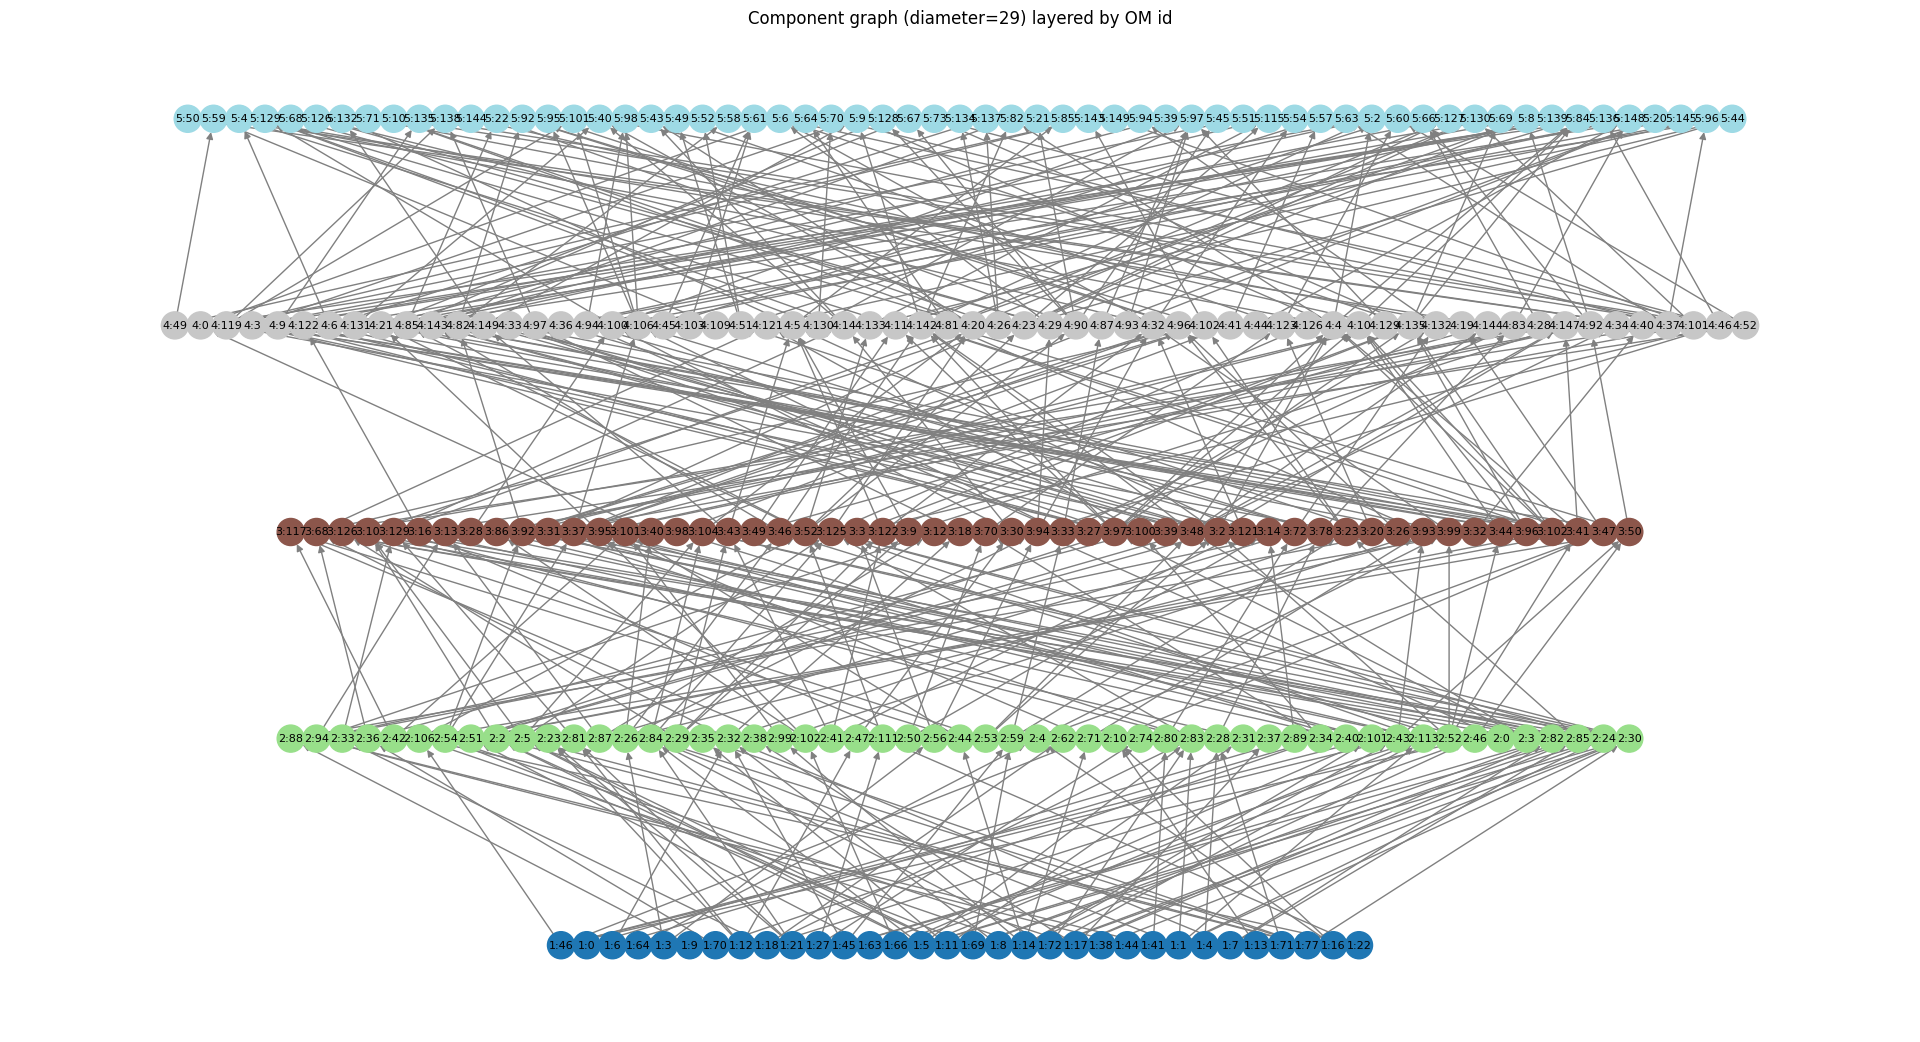

In [2]:
# Find and visualize the weak component with diameter=29 (fallback to max), and show its graph + all images
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

target_diameter = 29
threshold_used = 0.7  # must match the build you care about

print(f"=== Selecting component with diameter={target_diameter} (graph built at threshold={threshold_used}) ===")

# Build a fresh tracker with images loaded so we can render patches
tracker_comp = TreeTrackingGraph()
tracker_comp.load_data(load_images=True)
tracker_comp.build_graph_threshold(threshold=threshold_used)

UG = tracker_comp.G.to_undirected()
selected_comp = None
selected_diam = None
best_comp = None
best_diam = -1

for comp in nx.connected_components(UG):
    sub = UG.subgraph(comp)
    if sub.number_of_nodes() <= 1:
        diam = 0
    else:
        try:
            diam = nx.diameter(sub)
        except Exception:
            diam = 0
    if diam > best_diam:
        best_diam = diam
        best_comp = set(comp)
    if diam == target_diameter and selected_comp is None:
        selected_comp = set(comp)
        selected_diam = diam

if selected_comp is None:
    selected_comp = best_comp
    selected_diam = best_diam
    print(f"Target diameter {target_diameter} not found. Using max diameter component: {best_diam}.")
else:
    print(f"Found component with diameter {selected_diam}.")

nodes = sorted(list(selected_comp), key=lambda n: (n[0], n[1]))
print(f"Selected component has {len(nodes)} nodes.")
for om, cid in nodes:
    print(f"  OM {om} -> Crown {cid}")

# ------------------------------
# Visualization 1: Graph structure
# ------------------------------
H = tracker_comp.G.subgraph(selected_comp).copy()
for n in H.nodes:
    # Layer nodes by OM id for a clear, left-to-right structure
    H.nodes[n]['subset'] = n[0]

try:
    pos = nx.multipartite_layout(H, subset_key='subset', align='horizontal')
except Exception:
    pos = nx.spring_layout(H, seed=42)  # fallback

# Compute a decent figure width based on number of OM layers
unique_oms = sorted(set(n[0] for n in H.nodes))
fig_width = min(22, 4 + 3*len(unique_oms))
plt.figure(figsize=(fig_width, 10))
om_ids_sorted = sorted(set(n[0] for n in H.nodes))

# Robust colormap retrieval across matplotlib versions
manual_colors = False
try:
    cmap = plt.get_cmap('tab20', max(1, len(om_ids_sorted)))
except Exception:
    try:
        from matplotlib import colormaps as _cmaps
        cmap = _cmaps.get('tab20').resampled(max(1, len(om_ids_sorted)))
    except Exception:
        manual_colors = True

if manual_colors:
    colors = plt.rcParams.get('axes.prop_cycle', None)
    if colors is not None:
        colors = colors.by_key().get('color', ['#1f77b4'])
    else:
        colors = ['#1f77b4']
    node_colors = [colors[om_ids_sorted.index(n[0]) % len(colors)] for n in H.nodes]
else:
    node_colors = [cmap(om_ids_sorted.index(n[0])) for n in H.nodes]

nx.draw(H, pos, with_labels=False, node_color=node_colors, node_size=380, arrows=True, arrowsize=10, width=1.0, edge_color='gray')
labels = {n: f"{n[0]}:{n[1]}" for n in H.nodes}
nx.draw_networkx_labels(H, pos, labels, font_size=8)
plt.title(f"Component graph (diameter={selected_diam}) layered by OM id")
plt.axis('off')
plt.tight_layout()
plt.show()

# # ------------------------------
# # Visualization 2: All crown images in the component
# # ------------------------------
# # Order by OM then Crown for a nice grid
# nodes_img = nodes
# n = len(nodes_img)
# if n == 0:
#     print("No nodes to show.")
# else:
#     cols = min(6, max(1, int(np.ceil(np.sqrt(n)))))
#     rows = int(np.ceil(n / cols))
#     fig, axes = plt.subplots(rows, cols, figsize=(cols*3.2, rows*3.2))
#     if rows == 1 and cols == 1:
#         axes = np.array([[axes]])
#     elif rows == 1 or cols == 1:
#         axes = np.array(axes).reshape(rows, cols)

#     idx = 0
#     for r in range(rows):
#         for c in range(cols):
#             ax = axes[r, c]
#             if idx < n:
#                 om, cid = nodes_img[idx]
#                 patches = tracker_comp.crown_images.get(om, [])
#                 img = patches[cid] if cid < len(patches) else None
#                 if img is not None:
#                     ax.imshow(img)
#                 title = f"OM {om} • Crown {cid}" + ("" if img is not None else "\n(No image)")
#                 ax.set_title(title, fontsize=9)
#             ax.axis('off')
#             idx += 1
#     plt.suptitle(f"All tree images in selected component (n={n})", y=0.98)
#     plt.tight_layout()
#     plt.show()